<a href="https://colab.research.google.com/github/moramba2005/Projects/blob/master/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Block 1: Import libraries
import pandas as pd      # for tables, reading CSV, cleaning, calculations
import numpy as np       # for numeric operations (used inside pandas too)
import matplotlib.pyplot as plt  # for drawing plots

In [ ]:
# Block 2: Create a simple CSV file (run this once)

csv_data = """date,pm25,temp,humidity
2025-01-01,80,22,60
2025-01-02,90,23,62
2025-01-03,110,25,65
2025-01-04,130,28,68
2025-01-05,150,30,70
2025-01-06,140,31,72
2025-01-07,120,29,70
2025-01-08,100,27,68
2025-01-09,90,25,65
2025-01-10,85,24,63
2025-01-11,-5,26,64
2025-01-12,,28,66
"""

with open("aq_simple.csv", "w") as f:
    f.write(csv_data)

print("aq_simple.csv created")

aq_simple.csv created


In [ ]:
# Block 3: Read data from CSV into a pandas DataFrame

df = pd.read_csv("aq_simple.csv", parse_dates=["date"])

# Show first few rows
df.head()

,date,pm25,temp,humidity
0,2025-01-01,80.0,22,60
1,2025-01-02,90.0,23,62
2,2025-01-03,110.0,25,65
3,2025-01-04,130.0,28,68
4,2025-01-05,150.0,30,70


In [ ]:
# Block 4: Basic data cleaning

# 1) Remove rows where pm25 is missing
df = df.dropna(subset=["pm25"])

# 2) Remove rows with negative pm25 (invalid data)
df = df[df["pm25"] >= 0]

# 3) Fill missing temp with median temperature (if any are missing)
if df["temp"].isna().any():
    median_temp = df["temp"].median()
    df["temp"] = df["temp"].fillna(median_temp)

# 4) Fill missing humidity with median humidity (if any are missing)
if df["humidity"].isna().any():
    median_hum = df["humidity"].median()
    df["humidity"] = df["humidity"].fillna(median_hum)

# Show cleaned data
df

,date,pm25,temp,humidity
0,2025-01-01,80.0,22,60
1,2025-01-02,90.0,23,62
2,2025-01-03,110.0,25,65
3,2025-01-04,130.0,28,68
4,2025-01-05,150.0,30,70
5,2025-01-06,140.0,31,72
6,2025-01-07,120.0,29,70
7,2025-01-08,100.0,27,68
8,2025-01-09,90.0,25,65
9,2025-01-10,85.0,24,63


In [ ]:
# Block 5: Set date as index and create simple metrics

# Set 'date' as the index (row labels)
df = df.set_index("date")

# Metric 1: Bad air day (PM2.5 > 100)
# Creates a new column: 1 if bad air, else 0
df["bad_air_day"] = (df["pm25"] > 100).astype(int)

# Metric 2: Heat stress day (temp > 28 and humidity > 65)
# Creates a new column: 1 if heat stress, else 0
df["heat_stress_day"] = ((df["temp"] > 28) & (df["humidity"] > 65)).astype(int)

# Show the table with new columns
df[["pm25", "temp", "humidity", "bad_air_day", "heat_stress_day"]]

,pm25,temp,humidity,bad_air_day,heat_stress_day
date,,,,,
2025-01-01,80.0,22,60,0,0
2025-01-02,90.0,23,62,0,0
2025-01-03,110.0,25,65,1,0
2025-01-04,130.0,28,68,1,0
2025-01-05,150.0,30,70,1,1
2025-01-06,140.0,31,72,1,1
2025-01-07,120.0,29,70,1,1
2025-01-08,100.0,27,68,0,0
2025-01-09,90.0,25,65,0,0


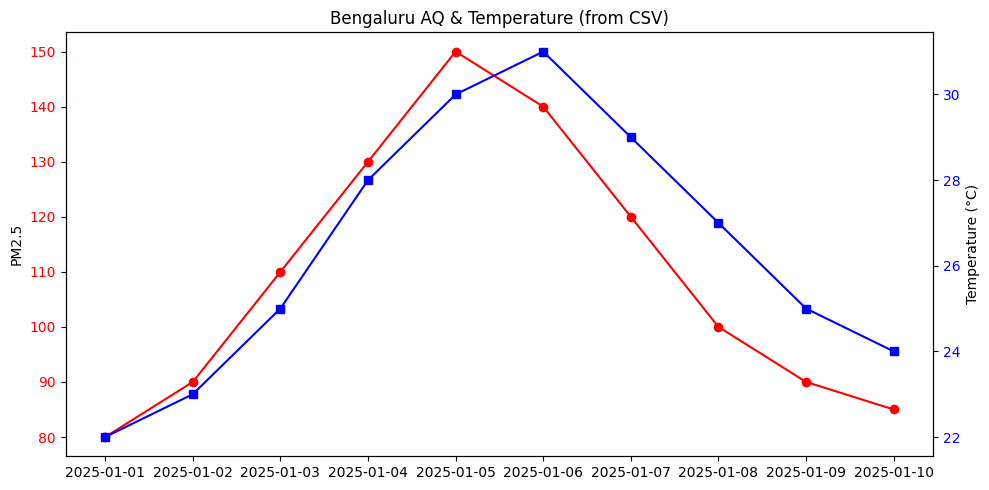

In [ ]:
# Block 6: Plot PM2.5 and temperature over time

fig, ax1 = plt.subplots(figsize=(10, 5))

# Left y-axis: PM2.5 (red line)
ax1.plot(df.index, df["pm25"], label="PM2.5", color="red", marker="o")
ax1.set_ylabel("PM2.5")
ax1.tick_params(axis="y", labelcolor="red")

# Right y-axis: Temperature (blue line)
ax2 = ax1.twinx()
ax2.plot(df.index, df["temp"], label="Temp", color="blue", marker="s")
ax2.set_ylabel("Temperature (°C)")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title("Bengaluru AQ & Temperature (from CSV)")
plt.tight_layout()
plt.show()

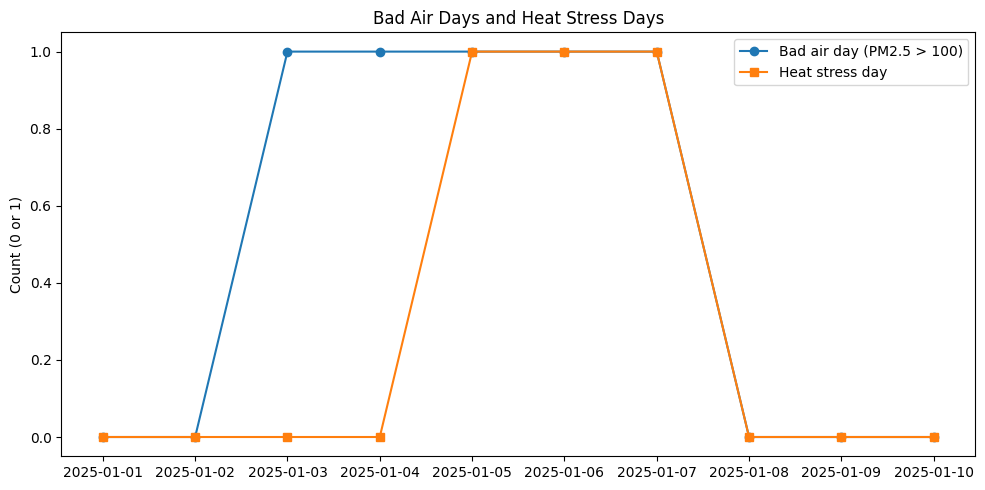

In [ ]:
# Block 7: Plot bad air days and heat stress days over time

plt.figure(figsize=(10, 5))

# Plot bad_air_day as a line with circle markers
plt.plot(df.index, df["bad_air_day"], marker="o", label="Bad air day (PM2.5 > 100)")

# Plot heat_stress_day as a line with square markers
plt.plot(df.index, df["heat_stress_day"], marker="s", label="Heat stress day")

plt.ylabel("Count (0 or 1)")
plt.title("Bad Air Days and Heat Stress Days")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Block 8: Show final cleaned data with metrics

df[["pm25", "temp", "humidity", "bad_air_day", "heat_stress_day"]]

,pm25,temp,humidity,bad_air_day,heat_stress_day
date,,,,,
2025-01-01,80.0,22,60,0,0
2025-01-02,90.0,23,62,0,0
2025-01-03,110.0,25,65,1,0
2025-01-04,130.0,28,68,1,0
2025-01-05,150.0,30,70,1,1
2025-01-06,140.0,31,72,1,1
2025-01-07,120.0,29,70,1,1
2025-01-08,100.0,27,68,0,0
2025-01-09,90.0,25,65,0,0
